# The Central Limit Theorem and Estimation of the Mean

**Definition.** For a fixed population and fixed sample size, the collection of all possible values of the mean over all possible samples of that size, forms what we call the **sampling distribution**.

Two vital theorems govern how these sampling distributions work:

1. **Central Limit Theorem.** The means of a sampling distribution are approximately normal (bell-shaped) and centered upon $\mu_0$, the population average.
2. **Law of Large Numbers.** As n increases, our estimates based upon the sample means increase in accuracy.

Thus, the CLT guarantees a bell-shaped distribution centered upon the population average, and the Law of Large Numbers works like a lever that allows us to control the accuracy. Increased sample sizes lead to increased accuracy.

## Data Sets

We will need some data to work with and the **mosaic** package loaded into R:

In [38]:
united <- read.csv('http://faculty.ung.edu/rsinn/data/united.csv')
airports <- read.csv('http://faculty.ung.edu/rsinn/data/airports.csv')
births <-  read.csv('http://faculty.ung.edu/rsinn/data/baby.csv')

library('mosaic')

We will use the function **sample()** which is in base R. We do not need to load any packages for it to be active.

## Example: Estimating Flight Delays

Let's work with an example from the **united** data set using the **Delay** column. Let's generate many, many samples of the same size. We'll find the averages from each sample and use them to estimate the average level of narcissism for students at UNG.

### First Step: Generating Samples of Size $n=10$

Let's beging with the R commands necessary to sample the **Delay** column in the **united** data frame. We will use the

<p style="color:red;">sample()</p>

function in R to draw the sample.

**Run the cell below to see how this works, and notice:**

- The function inputs:
1. Name of the data frame and column from which we will draw the sample (dollar sign method).
2. Sample size to be drawn.
3. Replace is set to TRUE or FALSE (draws with or without replacement).
- The output: 10 randomly selected rows of the **united** data frame.

In [39]:
s <- sample(united, size = 10, replace = TRUE)
s

,Date,Flight.Number,Destination,Delay,orig.id
,<chr>,<int>,<chr>,<int>,<chr>
11425,8/15/15,814,LAX,2,11425
5254,7/6/15,1227,EWR,10,5254
10564,8/10/15,72,LAX,0,10564
5573,7/8/15,1135,RDU,89,5573
12022,8/19/15,1111,LIH,-1,12022
8295,7/26/15,681,LAX,31,8295
3159,6/22/15,325,BOS,-1,3159
37,6/1/15,671,DEN,74,37
10383,8/8/15,1697,DEN,-1,10383


We need to subset the sample data frame **s** so that we have a numeric vector of **Delay** values. We will use the row-column method of subsetting:

In [42]:
delays <- sample(united, size = 10, replace = TRUE)[ , 'Delay']
head(delays)

[1] -2  6 -5  4  1 -6

We can find the average delay in minutes for these 10 flights.

In [43]:
mean(delays)

[1] 9.7

**Putting it Together.** Eventually, we want to run a loop that does this a thousand or more times. Thus, we prefer a single line of code that will do it for us all at once. We wrap the **sample()** function inside the **mean()** function as shown below.

**<span style='color:blue'>Run the code below multiple times to see how we're sampling plus finding the average Delay in minutes for each sample.</span>**

In [44]:
mean(sample(united, size = 10, replace = TRUE)[ , 'Delay'])

[1] 13

With the **do()** function from the **mosaic** package, we can repeat the process thousands (or millions) of times. In the output, each row is new sample of size 10.

In [48]:
delay_samples <- do(100) * sample(united, size = 10, replace = TRUE)[,'Delay']
head(delay_samples,20)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,64,2,-7,4,25,1,42,-5,1,-5
2,13,63,103,-4,18,0,29,-4,4,20
3,-1,-1,15,55,-4,-6,-4,-12,-5,12
4,1,0,-5,-2,-2,-5,0,12,56,95
5,1,6,2,-2,-4,2,2,14,-2,19
6,8,83,73,27,0,-1,6,22,0,0
7,25,94,-1,1,17,59,14,24,106,28
8,100,23,114,-6,25,-3,17,3,15,18
9,-5,35,2,47,22,11,-1,0,-5,-2


What we would like is a numeric vector for the means of all of these samples:

In [50]:
mean_delay_samples <- do(100) * mean(sample(united, size = 10, replace = TRUE)[,'Delay'])
head(mean_delay_samples,7)

,mean
,<dbl>
1,8.2
2,21.7
3,21.1
4,15.8
5,6.3
6,7.4
7,6.4


### Step 2: Creating a for Loop

The steps make sense if we consider them separately:

1. Create **all_means**, an initially empty vector where we plan to store our sample means.
2. Create a for loop that will a thousand times.
3. Inside the loop, we will:
  - Gather a sample of size $n=10$.
  - Calcuate the mean.
  - Add this value to the **all_means** vector.

In [57]:
reps = 100
n = 10
all_means <- do(reps) * mean(sample(united, size = n, replace = TRUE)[,'Delay'])
head(all_means)

,mean
,<dbl>
1,23.3
2,25.1
3,11.0
4,17.0
5,51.4
6,20.1


Notice that we now have a vector **all_means**, so we display the distribution in a histogram and caculate various statistics.

The grand mean from the simulation =  16.714

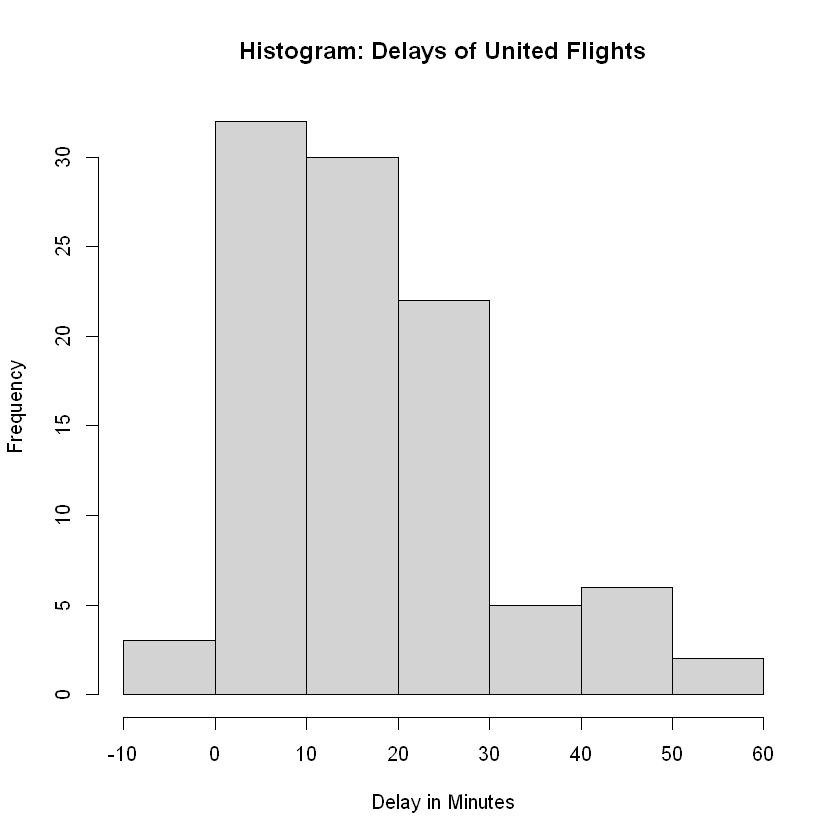

In [62]:
cat('The grand mean from the simulation = ', mean(all_means$mean))
hist(all_means$mean, main = 'Histogram: Delays of United Flights', xlab = 'Delay in Minutes')

### Step 3: The Middle 90% of the Distribution

Because we intend to use the sampling distributions to estimate the population average, we need a way to gather an interval. This interval will be our estimated range of values. For the moment, let's use the **middle 90%** of the **all_means** vector. We will need the endpoints, e.g. the 5th and 95th percentiles from the vector.

```{tip}
Notice the function **na.omit**. When the data vector has too many undefined values, the statistical functions sometimes fail. We can circumvent this behavior by omitting the NA values in the data vector.
```

In [63]:
lower <- quantile(all_means$mean, prob = 0.05)     # Calcuate the 5th percentile.
upper <- quantile(all_means$mean, prob = 0.95)     # Calcuate the 95th percentile.
cat('The middle 90% of the all_means vector is (',lower,',',upper,').')

The middle 90% of the all_means vector is ( 0.5 , 41.905 ).

### Step 4: The Histogram with Vertical Lines Showing the 5th and 95th Percentiles

We use the function **abline()** to superimpose vertical lines onto our histogram. We've already calculated the values for the 5th and 95th percentiles. We need only to use the option **v** which draws a *vertical line* at the value indicated. The color option is not vital for our purposes, but a splash of color is visually appealing.

As we go forward, we will see that increased sample size will lead to a narrower bell-shape. In other words, the size of the standard deviation will become important, so let's include that in the text we print out using the **cat()** function.

The grand mean from the simulation =  16.714 
The middle 90% of the sampling distribution: is ( 0.5 , 41.905 ).

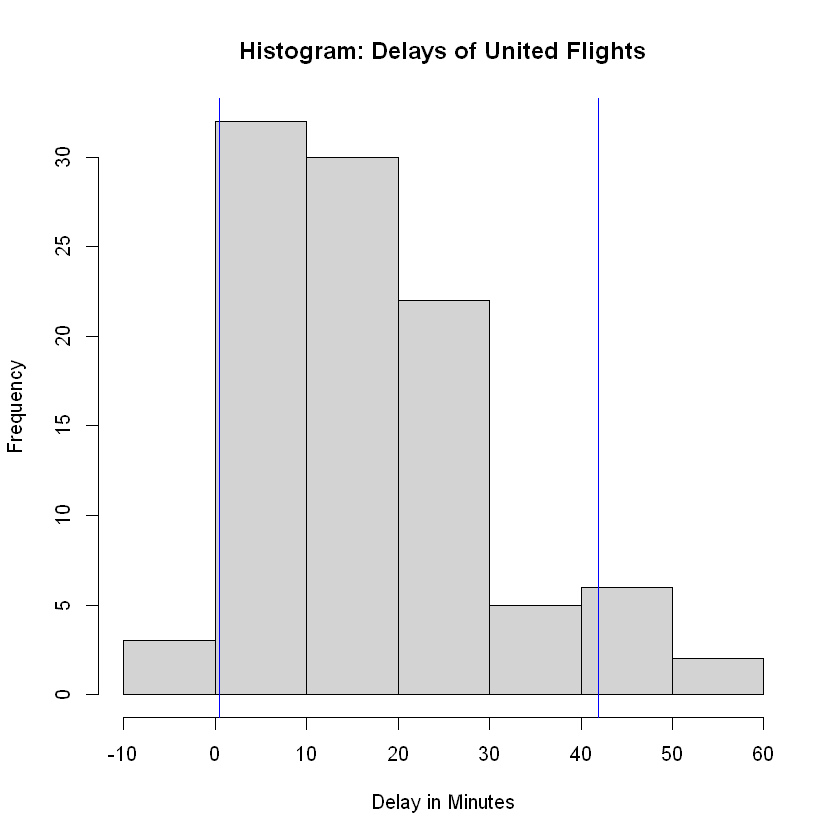

In [66]:
cat('The grand mean from the simulation = ', mean(all_means$mean),'\nThe middle 90% of the sampling distribution: is (',lower,',',upper,').')
hist(all_means$mean, main = 'Histogram: Delays of United Flights', xlab = 'Delay in Minutes')
abline( v = lower, col="blue")
abline(v = upper, col="blue")

### Step 5: Performing all Tasks in 1 Code Block

Now that we have unpacked each command line needed, we can put it all together into one code block. Doing so will help to quickly generate different sampling distributions for different sample sizes **n**.

The grand mean from the simulation =  17.589 
The middle 90% of the sampling distribution: is ( 1.49 , 41.475 ).

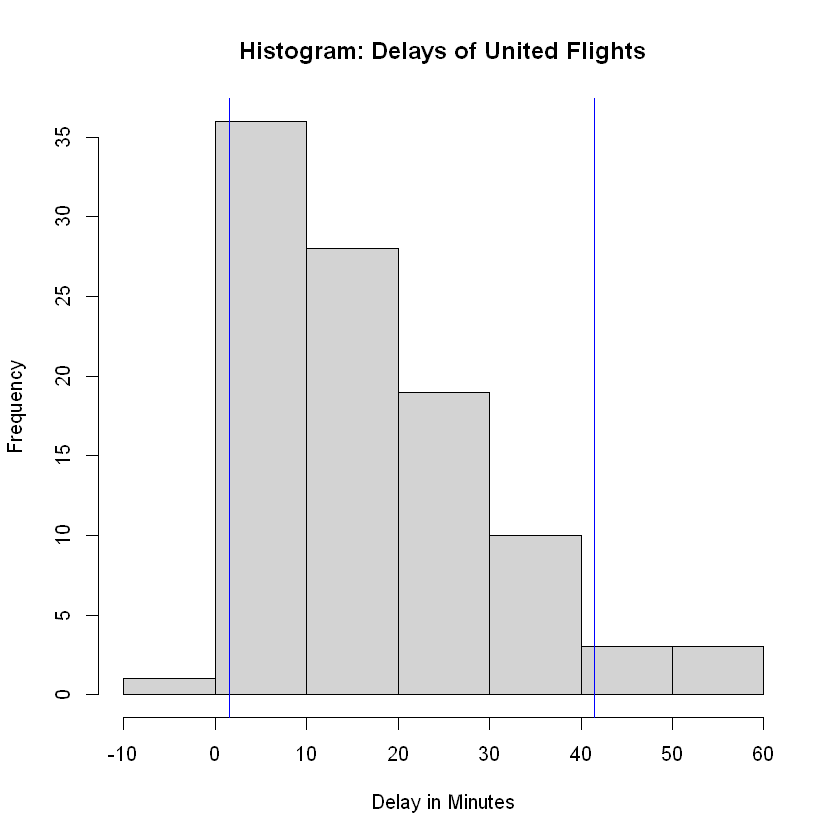

In [79]:
reps = 100
n = 10
all_means <- do(reps) * mean(sample(united, size = n, replace = TRUE)[,'Delay'])

upper <- quantile(all_means$mean, prob = 0.95)
lower <- quantile(all_means$mean, prob = 0.05)
cat('The grand mean from the simulation = ', mean(all_means$mean),'\nThe middle 90% of the sampling distribution: is (',lower,',',upper,').')
hist(all_means$mean, main = 'Histogram: Delays of United Flights', xlab = 'Delay in Minutes')
abline( v = lower, col="blue")
abline(v = upper, col="blue")

## Task

Let's increase the sample size. We will conduct the same simulation for sample sizes:

- 100
- 200
- 500
- 1000

After doing so, we will fill in the table below with the values we found:

<table class="center" style="width:80%; text-align:center;">
  <tr>
    <th>Repititions</th>
    <th>Sample Size</th> 
    <th>Grand Mean from Simulation </th>
    <th>Middle 90% of Simulated Data</th>
  </tr>
  <tr>
    <td>1,000</td>
    <td>100</td>
    <td>xx</td>
    <td>yy</td>
  </tr>
  <tr>
    <td>1,000</td>
    <td>200</td>
    <td>xx</td>
    <td>yy</td>
  </tr>
  <tr>
    <td>1,000</td>
    <td>500</td>
    <td>xx</td>
    <td>yy</td>
  </tr>
  <tr>
    <td>1,000</td>
    <td>1,000</td>
    <td>xx</td>
    <td>yy</td>
  </tr>
</table>

## Task 2

Using the **airports** data frame, estimate the mean **Elevation** for Georgia airports and heliports.

## Task 3

Using the **births** data frame, estimate the mean **Birth.Weight** in ounces for the birth weights of the babies in the data frame.